In [3]:
#!/usr/bin/env python3
# build_ml_tree_iqtree.py

from pathlib import Path
import subprocess
import shutil
import sys
from Bio import Entrez, SeqIO


# -----------------------------
# 1. Input data
# -----------------------------

ACCESSIONS = {
    "KJ434962": "Allenopithecus_nigroviridis",
    "KT159932": "Cercocebus_atys",
    "KC757390": "Cercocebus_chrysogaster",
    "KJ434959": "Cercocebus_torquatus",
    "AY863426": "Cercopithecus_aethiops",
    "KC757391": "Cercopithecus_albogularis",
    "KJ434958": "Cercopithecus_diana",
    "KJ434957": "Cercopithecus_lhoesti",
    "KJ434956": "Cercopithecus_mitis",
    "MW160353": "Cercopithecus_neglectus",
    "KU682691": "Chlorocebus_aethiops_C1",
    "MN816163": "Chlorocebus_aethiops",
    "KU682693": "Chlorocebus_cynosuros_C3",
    "KM262190": "Chlorocebus_cynosuros",
    "KU682695": "Chlorocebus_djamdjamensis_C5",
}


# Use your real email here. NCBI asks users of Entrez to identify themselves.
Entrez.email = "your_email@example.com"


# -----------------------------
# 2. Utility functions
# -----------------------------

def require_executable(name_candidates):
    """
    Return the first executable found in PATH.
    """
    for name in name_candidates:
        path = shutil.which(name)
        if path is not None:
            return path
    raise RuntimeError(
        f"Cannot find any of these executables in PATH: {name_candidates}\n"
        f"Install them, for example:\n"
        f"  conda install -c bioconda mafft iqtree\n"
    )


def run_command(cmd, stdout_path=None, stderr_path=None):
    """
    Run external command safely.
    """
    print("\nRunning:")
    print(" ".join(map(str, cmd)))

    stdout_handle = None
    stderr_handle = None

    try:
        if stdout_path is not None:
            stdout_handle = open(stdout_path, "w", encoding="utf-8")
        if stderr_path is not None:
            stderr_handle = open(stderr_path, "w", encoding="utf-8")

        result = subprocess.run(
            list(map(str, cmd)),
            stdout=stdout_handle if stdout_handle else subprocess.PIPE,
            stderr=stderr_handle if stderr_handle else subprocess.PIPE,
            text=True,
            check=False,
        )

        if result.returncode != 0:
            if result.stderr:
                print(result.stderr)
            raise RuntimeError(f"Command failed with exit code {result.returncode}")

    finally:
        if stdout_handle:
            stdout_handle.close()
        if stderr_handle:
            stderr_handle.close()


def download_fasta(accessions, output_fasta):
    """
    Download sequences from NCBI nucleotide database in FASTA format.
    """
    ids = ",".join(accessions)
    print(f"Downloading {len(accessions)} sequences from NCBI...")

    with Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text",
    ) as handle:
        fasta_text = handle.read()

    output_fasta.write_text(fasta_text, encoding="utf-8")
    print(f"Saved raw FASTA: {output_fasta}")


def sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv):
    """
    Replace NCBI FASTA headers with stable short labels:
    Species_accession

    This avoids problems with spaces/special symbols in tree software.
    """
    records = list(SeqIO.parse(raw_fasta, "fasta"))

    found = set()
    clean_records = []

    with open(mapping_tsv, "w", encoding="utf-8") as map_out:
        map_out.write("new_label\taccession\toriginal_header\n")

        for rec in records:
            # NCBI FASTA id may look like KJ434962.1, so remove version suffix.
            acc_full = rec.id
            acc_base = acc_full.split(".")[0]

            if acc_base not in ACCESSIONS:
                raise ValueError(f"Unexpected accession in downloaded FASTA: {rec.id}")

            label = f"{ACCESSIONS[acc_base]}_{acc_base}"

            rec.id = label
            rec.name = label
            rec.description = ""

            clean_records.append(rec)
            found.add(acc_base)

            map_out.write(f"{label}\t{acc_base}\t{acc_full}\n")

    missing = set(ACCESSIONS) - found
    if missing:
        raise ValueError(f"These accessions were not downloaded: {sorted(missing)}")

    SeqIO.write(clean_records, clean_fasta, "fasta")
    print(f"Saved sanitized FASTA: {clean_fasta}")
    print(f"Saved label mapping: {mapping_tsv}")


# -----------------------------
# 3. Main pipeline
# -----------------------------

def main():
    outdir = Path("mtDNA15_ML_tree")
    outdir.mkdir(exist_ok=True)

    raw_fasta = outdir / "mtDNA15_raw.fasta"
    clean_fasta = outdir / "mtDNA15_clean.fasta"
    aligned_fasta = outdir / "mtDNA15_aligned_mafft.fasta"
    mapping_tsv = outdir / "label_mapping.tsv"

    mafft_log = outdir / "mafft.stderr.log"

    prefix = outdir / "mtDNA15_IQTREE_ML"
    treefile = Path(str(prefix) + ".treefile")

    mafft = require_executable(["mafft"])
    iqtree = require_executable(["iqtree2", "iqtree3", "iqtree"])

    print(f"Using MAFFT: {mafft}")
    print(f"Using IQ-TREE: {iqtree}")

    # Step 1: Download FASTA
    if not raw_fasta.exists():
        download_fasta(list(ACCESSIONS.keys()), raw_fasta)
    else:
        print(f"Raw FASTA already exists, skipping download: {raw_fasta}")

    # Step 2: Sanitize FASTA headers
    sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv)

    # Step 3: Multiple sequence alignment with MAFFT
    # For full mitochondrial genomes, --auto is a safe default.
    # If you want a slower but often more accurate mode, replace with:
    # ["mafft", "--localpair", "--maxiterate", "1000", clean_fasta]
    run_command(
        [mafft, "--auto", clean_fasta],
        stdout_path=aligned_fasta,
        stderr_path=mafft_log,
    )

    print(f"Saved MAFFT alignment: {aligned_fasta}")

    # Step 4: ML tree with IQ-TREE
    #
    # -m MFP     : ModelFinder Plus; selects best-fit substitution model
    # -B 1000    : ultrafast bootstrap, IQ-TREE 2/3 syntax
    # -alrt 1000 : SH-aLRT support
    # -T AUTO    : automatic thread selection
    #
    # If your IQ-TREE is old and does not support -B/-T,
    # use -bb 1000 and -nt AUTO instead.
    cmd = [
        iqtree,
        "-s", aligned_fasta,
        "-m", "MFP",
        "-B", "1000",
        "-alrt", "1000",
        "-T", "AUTO",
        "--prefix", prefix,
    ]

    run_command(cmd)

    if not treefile.exists():
        raise FileNotFoundError(
            f"IQ-TREE finished, but treefile was not found: {treefile}"
        )

    print("\nDone.")
    print(f"ML reference tree:")
    print(treefile)
    print("\nOther useful IQ-TREE outputs:")
    print(Path(str(prefix) + ".iqtree"))
    print(Path(str(prefix) + ".log"))
    print(Path(str(prefix) + ".contree"))
    print(Path(str(prefix) + ".ufboot"))


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print("\nERROR:", e, file=sys.stderr)
        sys.exit(1)


ERROR: Cannot find any of these executables in PATH: ['mafft']
Install them, for example:
  conda install -c bioconda mafft iqtree



SystemExit: 1

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [2]:
!pip install Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [Bio]3/6 [biothings-client]

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
# One-cell Jupyter pipeline:
# NCBI FASTA download -> MAFFT alignment -> IQ-TREE ML reference tree

from pathlib import Path
import subprocess
import shutil
import sys
import importlib.util

# -----------------------------
# 0. Install Biopython into current Jupyter kernel if missing
# -----------------------------
if importlib.util.find_spec("Bio") is None:
    print("Biopython not found. Installing into current Jupyter kernel...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "biopython"])

from Bio import Entrez, SeqIO


# -----------------------------
# 1. User settings
# -----------------------------

# Replace with your real email. NCBI asks Entrez users to identify themselves.
NCBI_EMAIL = "your_email@example.com"

# Output folder
OUTDIR = Path("mtDNA15_ML_tree")
OUTDIR.mkdir(exist_ok=True)

# If MAFFT / IQ-TREE are not in PATH, write full paths here, for example:
# MAFFT_EXE = r"C:\path\to\mafft.bat"
# IQTREE_EXE = r"C:\path\to\iqtree2.exe"
MAFFT_EXE = None
IQTREE_EXE = None

# IQ-TREE prefix
PREFIX = OUTDIR / "mtDNA15_IQTREE_ML"

# Accessions and short labels
ACCESSIONS = {
    "KJ434962": "Allenopithecus_nigroviridis",
    "KT159932": "Cercocebus_atys",
    "KC757390": "Cercocebus_chrysogaster",
    "KJ434959": "Cercocebus_torquatus",
    "AY863426": "Cercopithecus_aethiops",
    "KC757391": "Cercopithecus_albogularis",
    "KJ434958": "Cercopithecus_diana",
    "KJ434957": "Cercopithecus_lhoesti",
    "KJ434956": "Cercopithecus_mitis",
    "MW160353": "Cercopithecus_neglectus",
    "KU682691": "Chlorocebus_aethiops_C1",
    "MN816163": "Chlorocebus_aethiops",
    "KU682693": "Chlorocebus_cynosuros_C3",
    "KM262190": "Chlorocebus_cynosuros",
    "KU682695": "Chlorocebus_djamdjamensis_C5",
}


# -----------------------------
# 2. Helper functions
# -----------------------------

def find_executable(user_path, candidates):
    """
    Find executable either from user-specified path or from PATH.
    """
    if user_path:
        p = Path(user_path)
        if p.exists():
            return str(p)
        raise FileNotFoundError(f"Specified executable does not exist: {user_path}")

    for name in candidates:
        path = shutil.which(name)
        if path is not None:
            return path

    raise FileNotFoundError(
        f"Cannot find executable. Tried: {candidates}\n"
        f"Install it in your current system or set full path manually."
    )


def run_command(cmd, stdout_path=None, stderr_path=None):
    """
    Run external command and show useful error if it fails.
    """
    print("\nRunning command:")
    print(" ".join(map(str, cmd)))

    stdout_handle = open(stdout_path, "w", encoding="utf-8") if stdout_path else None
    stderr_handle = open(stderr_path, "w", encoding="utf-8") if stderr_path else None

    try:
        result = subprocess.run(
            list(map(str, cmd)),
            stdout=stdout_handle if stdout_handle else subprocess.PIPE,
            stderr=stderr_handle if stderr_handle else subprocess.PIPE,
            text=True,
            check=False,
        )

        if result.returncode != 0:
            if result.stderr:
                print("\nSTDERR:")
                print(result.stderr)
            raise RuntimeError(f"Command failed with exit code {result.returncode}")

        if result.stdout and not stdout_path:
            print(result.stdout[:1000])

    finally:
        if stdout_handle:
            stdout_handle.close()
        if stderr_handle:
            stderr_handle.close()


def download_fasta(accessions, output_fasta):
    """
    Download FASTA sequences from NCBI nucleotide database.
    """
    Entrez.email = NCBI_EMAIL
    ids = ",".join(accessions)

    print(f"Downloading {len(accessions)} sequences from NCBI...")
    with Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text",
    ) as handle:
        fasta_text = handle.read()

    output_fasta.write_text(fasta_text, encoding="utf-8")
    print(f"Saved raw FASTA: {output_fasta}")


def sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv):
    """
    Replace NCBI FASTA headers with short stable labels.
    IQ-TREE and tree-comparison tools work better with clean labels.
    """
    records = list(SeqIO.parse(raw_fasta, "fasta"))

    if len(records) == 0:
        raise ValueError("Downloaded FASTA contains no records.")

    found = set()
    clean_records = []

    with open(mapping_tsv, "w", encoding="utf-8") as fout:
        fout.write("new_label\taccession\toriginal_id\toriginal_description\n")

        for rec in records:
            acc_full = rec.id
            acc_base = acc_full.split(".")[0]

            if acc_base not in ACCESSIONS:
                raise ValueError(
                    f"Unexpected accession in FASTA: {acc_full}\n"
                    f"Original description: {rec.description}"
                )

            new_label = f"{ACCESSIONS[acc_base]}_{acc_base}"

            fout.write(
                f"{new_label}\t{acc_base}\t{acc_full}\t{rec.description}\n"
            )

            rec.id = new_label
            rec.name = new_label
            rec.description = ""

            clean_records.append(rec)
            found.add(acc_base)

    missing = set(ACCESSIONS.keys()) - found
    if missing:
        raise ValueError(f"These accessions were not found in downloaded FASTA: {sorted(missing)}")

    SeqIO.write(clean_records, clean_fasta, "fasta")
    print(f"Saved clean FASTA: {clean_fasta}")
    print(f"Saved label mapping: {mapping_tsv}")


# -----------------------------
# 3. File paths
# -----------------------------

raw_fasta = OUTDIR / "mtDNA15_raw.fasta"
clean_fasta = OUTDIR / "mtDNA15_clean.fasta"
aligned_fasta = OUTDIR / "mtDNA15_aligned_mafft.fasta"
mapping_tsv = OUTDIR / "label_mapping.tsv"
mafft_log = OUTDIR / "mafft.stderr.log"

treefile = Path(str(PREFIX) + ".treefile")
contree = Path(str(PREFIX) + ".contree")
iqtree_report = Path(str(PREFIX) + ".iqtree")
iqtree_log = Path(str(PREFIX) + ".log")


# -----------------------------
# 4. Find MAFFT and IQ-TREE
# -----------------------------

mafft = find_executable(MAFFT_EXE, ["mafft", "mafft.bat"])
iqtree = find_executable(IQTREE_EXE, ["iqtree2", "iqtree3", "iqtree"])

print(f"MAFFT executable: {mafft}")
print(f"IQ-TREE executable: {iqtree}")


# -----------------------------
# 5. Download sequences
# -----------------------------

if raw_fasta.exists():
    print(f"Raw FASTA already exists, skipping download: {raw_fasta}")
else:
    download_fasta(list(ACCESSIONS.keys()), raw_fasta)


# -----------------------------
# 6. Clean FASTA labels
# -----------------------------

sanitize_fasta(raw_fasta, clean_fasta, mapping_tsv)


# -----------------------------
# 7. Multiple sequence alignment with MAFFT
# -----------------------------

# Default and usually safe:
mafft_cmd = [
    mafft,
    "--auto",
    str(clean_fasta),
]

# Slower but sometimes more accurate for difficult alignments:
# mafft_cmd = [
#     mafft,
#     "--localpair",
#     "--maxiterate", "1000",
#     str(clean_fasta),
# ]

run_command(
    mafft_cmd,
    stdout_path=aligned_fasta,
    stderr_path=mafft_log,
)

print(f"Saved MAFFT alignment: {aligned_fasta}")


# -----------------------------
# 8. ML tree inference with IQ-TREE
# -----------------------------

# Modern IQ-TREE 2/3 syntax:
# -m MFP      automatic model selection
# -B 1000     ultrafast bootstrap
# -alrt 1000  SH-aLRT support
# -T AUTO     automatic thread selection

iqtree_cmd = [
    iqtree,
    "-s", str(aligned_fasta),
    "-m", "MFP",
    "-B", "1000",
    "-alrt", "1000",
    "-T", "AUTO",
    "--prefix", str(PREFIX),
]

try:
    run_command(iqtree_cmd)
except RuntimeError:
    print("\nModern IQ-TREE command failed. Trying older syntax with -bb and -nt...")

    old_iqtree_cmd = [
        iqtree,
        "-s", str(aligned_fasta),
        "-m", "MFP",
        "-bb", "1000",
        "-alrt", "1000",
        "-nt", "AUTO",
        "--prefix", str(PREFIX),
    ]

    run_command(old_iqtree_cmd)


# -----------------------------
# 9. Final output
# -----------------------------

if not treefile.exists():
    raise FileNotFoundError(
        f"IQ-TREE finished, but treefile was not found:\n{treefile}"
    )

print("\nDONE")
print("Main ML reference tree:")
print(treefile)

print("\nOther useful files:")
for p in [contree, iqtree_report, iqtree_log, aligned_fasta, mapping_tsv]:
    if p.exists():
        print(p)

print("\nRecommended manuscript wording:")
print(
    "Because the true phylogeny of the empirical mtDNA dataset is unknown, "
    "we inferred a maximum-likelihood reference tree from the complete mtDNA alignment. "
    "The 15 mitochondrial genomes were aligned with MAFFT, and the ML tree was inferred "
    "with IQ-TREE using automatic model selection and 1000 ultrafast bootstrap replicates. "
    "Trees reconstructed from completed distance matrices were compared against this ML "
    "reference topology using normalized Robinson--Foulds distance."
)


MAFFT executable: /usr/bin/mafft
IQ-TREE executable: /usr/bin/iqtree2
Saved raw FASTA: mtDNA15_ML_tree/mtDNA15_raw.fasta
Saved clean FASTA: mtDNA15_ML_tree/mtDNA15_clean.fasta
Saved label mapping: mtDNA15_ML_tree/label_mapping.tsv

Running command:
/usr/bin/mafft --auto mtDNA15_ML_tree/mtDNA15_clean.fasta
Saved MAFFT alignment: mtDNA15_ML_tree/mtDNA15_aligned_mafft.fasta

Running command:
/usr/bin/iqtree2 -s mtDNA15_ML_tree/mtDNA15_aligned_mafft.fasta -m MFP -B 1000 -alrt 1000 -T AUTO --prefix mtDNA15_ML_tree/mtDNA15_IQTREE_ML
IQ-TREE multicore version 2.0.7 for Linux 64-bit built Jan 21 2022
Developed by Bui Quang Minh, Nguyen Lam Tung, Olga Chernomor,
Heiko Schmidt, Dominik Schrempf, Michael Woodhams.

Host:    DESKTOP-1BN4F8D (AVX2, FMA3, 62 GB RAM)
Command: /usr/bin/iqtree2 -s mtDNA15_ML_tree/mtDNA15_aligned_mafft.fasta -m MFP -B 1000 -alrt 1000 -T AUTO --prefix mtDNA15_ML_tree/mtDNA15_IQTREE_ML
Seed:    97093 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Mon J

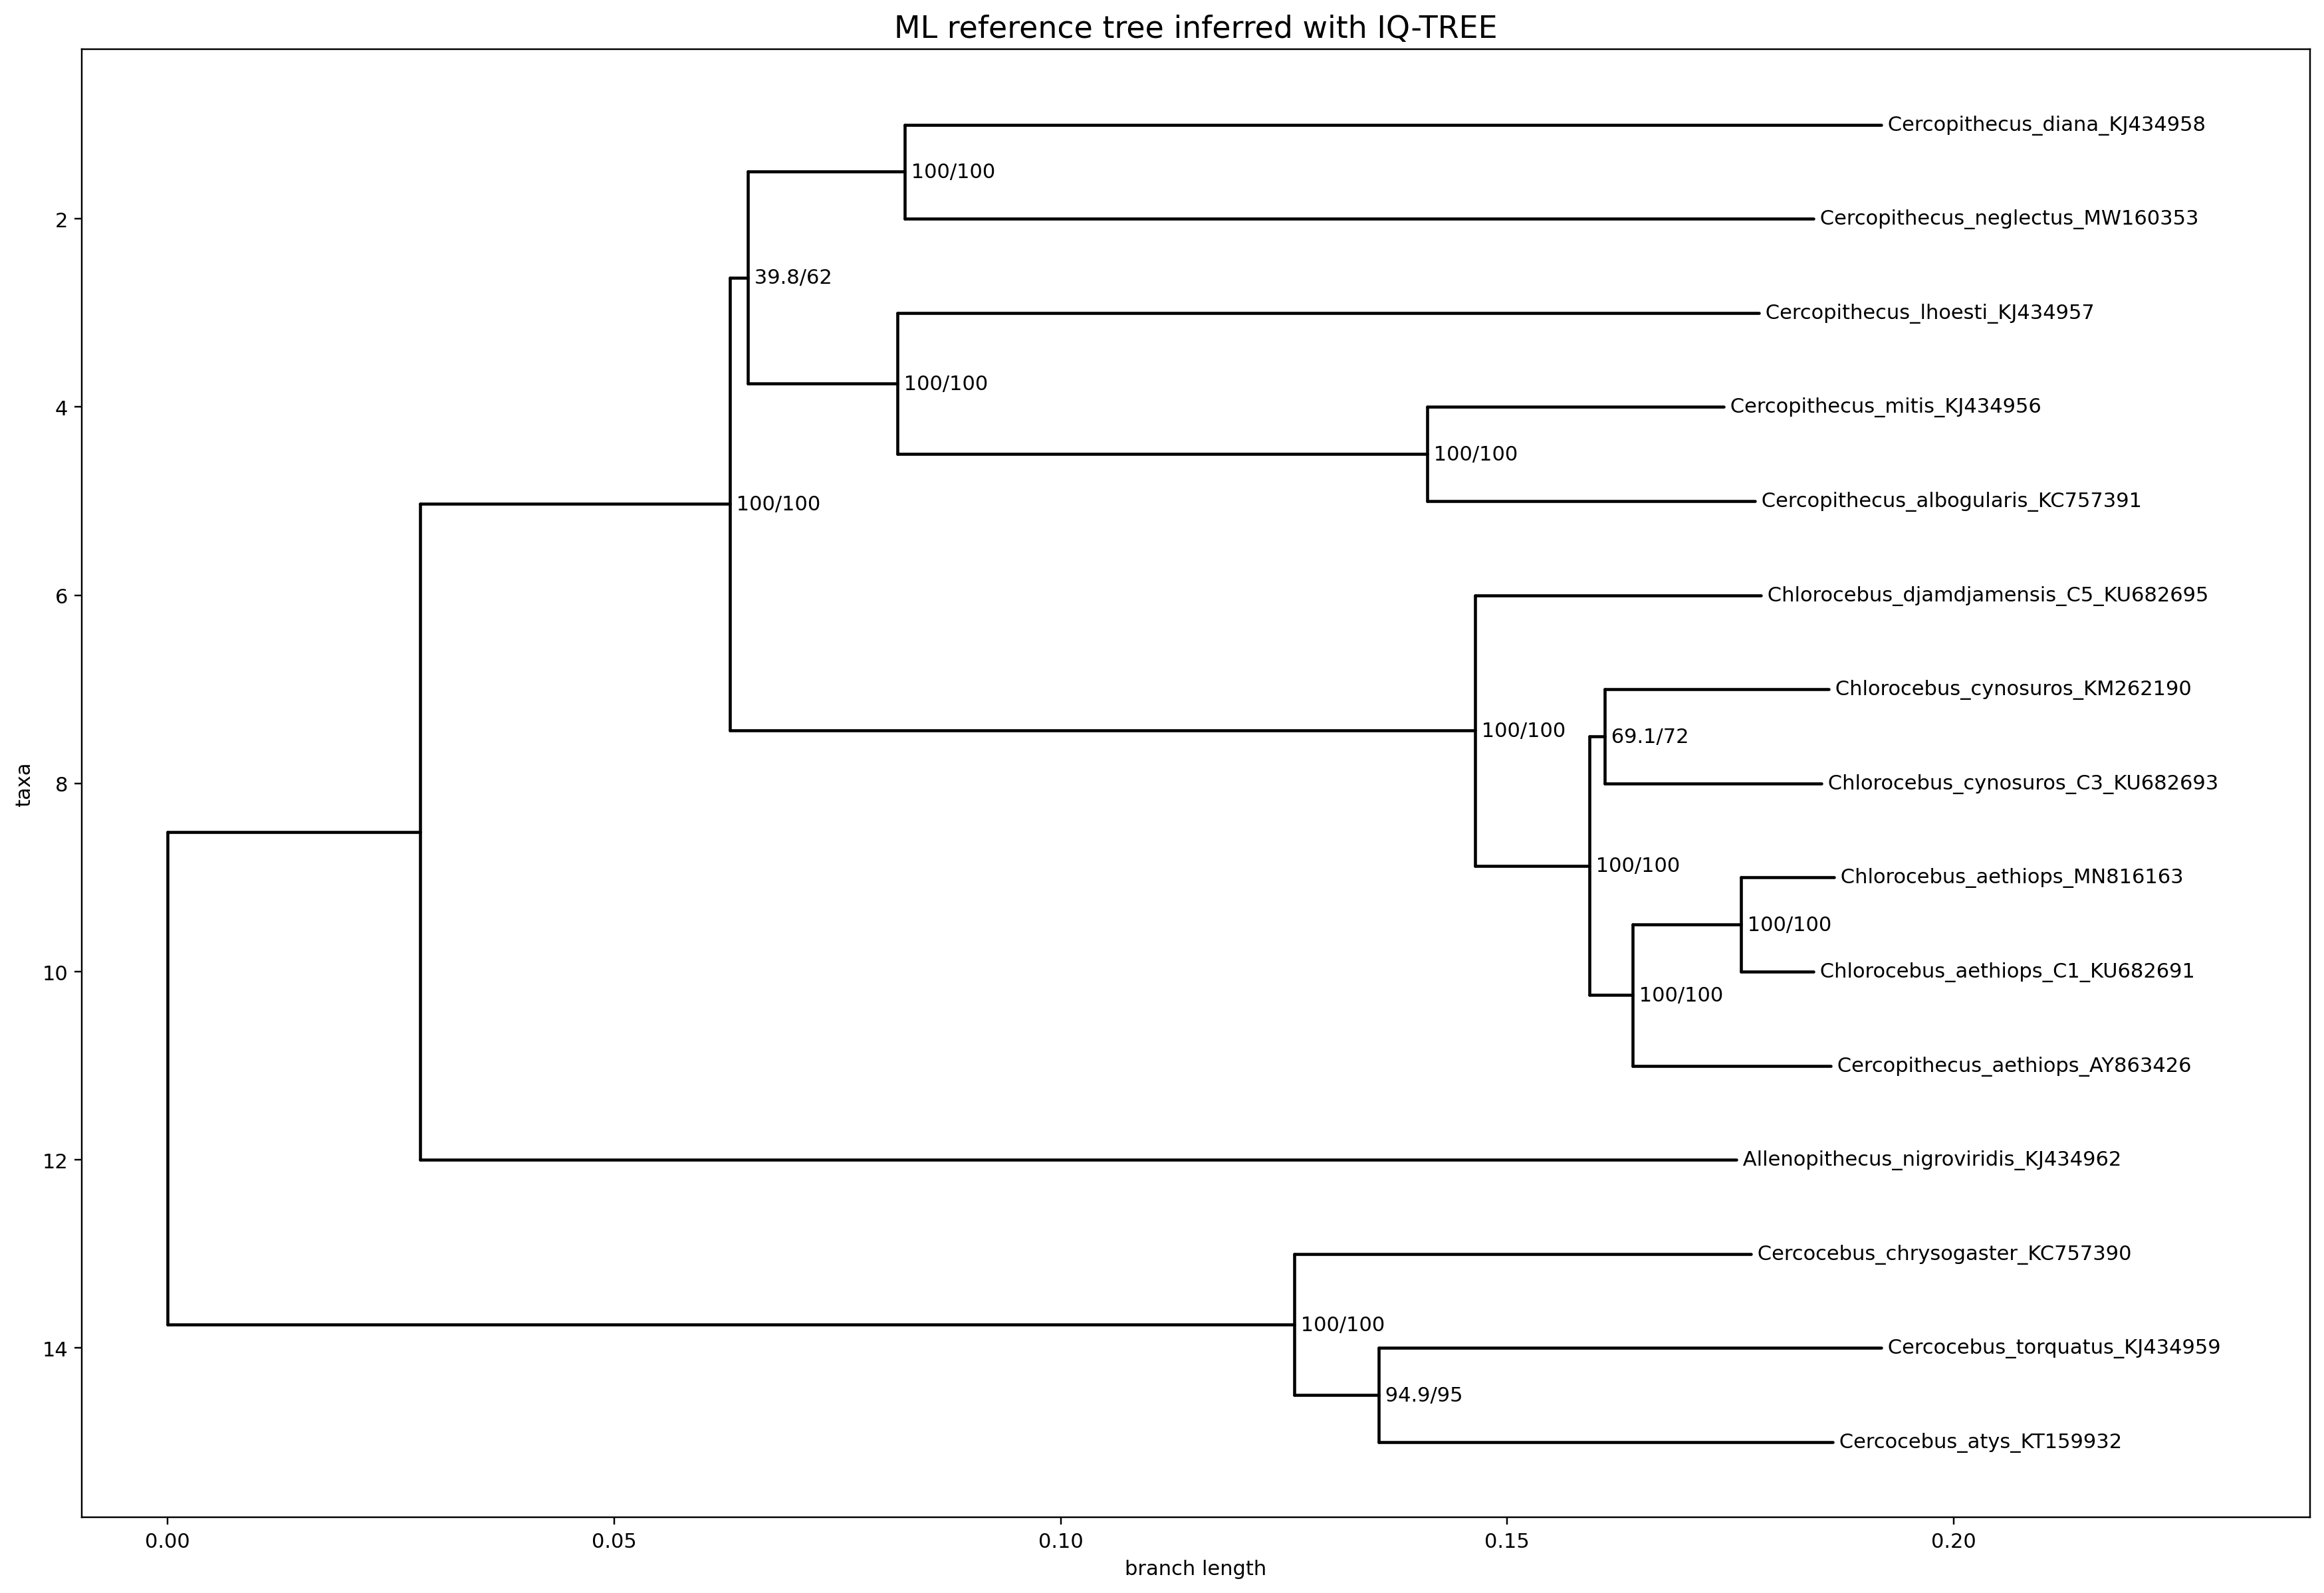

Saved: mtDNA15_ML_tree/mtDNA15_IQTREE_ML_tree_large_labels.png


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from Bio import Phylo

tree_path = "mtDNA15_ML_tree/mtDNA15_IQTREE_ML.treefile"
out_png = "mtDNA15_ML_tree/mtDNA15_IQTREE_ML_tree_large_labels.png"

tree = Phylo.read(tree_path, "newick")
tree.root_at_midpoint()

fig = plt.figure(figsize=(16, 11), dpi=220)
ax = fig.add_subplot(1, 1, 1)

Phylo.draw(
    tree,
    axes=ax,
    do_show=False,
    show_confidence=True,
    label_func=lambda clade: clade.name if clade.name else None
)

for text in ax.texts:
    text.set_fontsize(10)

ax.set_title("ML reference tree inferred with IQ-TREE", fontsize=15)
plt.tight_layout()
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)